# Organised Crime & Cybercrime in Europe
## Notebook 2: Exploratory Data Analysis (EDA)

**Prerequisite:** Run `01_data_loading_and_merging.ipynb` first.

This notebook covers:
- Univariate & bivariate distributions
- Time trends across Europe
- Country-level profiles
- Correlation analysis
- Missing data visualisation


In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Consistent style
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Load merged dataset
df = pd.read_csv('eu_crime_cyber_merged.csv')
df_crime_long = pd.read_csv('crime_cleaned.csv')
df_cyber = pd.read_csv('cyber_cleaned.csv')

print(f'Merged dataset: {df.shape}')
print(f'Crime (long): {df_crime_long.shape}')
print(f'Cyber: {df_cyber.shape}')
display(df.head(3))

Merged dataset: (409, 30)
Crime (long): (14272, 7)
Cyber: (6028, 6)


,country_code,year,Acts against computer system,Acts involving the movement or dumping of waste,Acts that result in the depletion or degradation of natural resources,Assault,Attempted homicide,Bribery,Burglary,Burglary of private residential premises,...,Serious Assault,Sexual exploitation,Sexual violence,Theft,Theft of a motorized vehicle or parts thereof,Trade or possession of protected or prohibited species of fauna and flora,Unlawful acts involving controlled drugs or precursors,cyber_incident_pct_mean,cyber_incident_pct_max,country_name
0,AT,2010,NaN,NaN,NaN,2302.24,113.34,NaN,89567.77,14821.37,...,3649.18,NaN,3537.86,152532.77,5211.66,NaN,2192.95,77.172857,96.39,Austria
1,AT,2011,NaN,NaN,NaN,2674.56,106.25,NaN,85283.27,15802.46,...,3943.53,NaN,4004.25,146049.26,5219.59,NaN,2347.70,78.673889,97.36,Austria
2,AT,2012,NaN,NaN,NaN,2817.11,110.30,NaN,86251.76,15663.10,...,4077.93,NaN,4088.05,148262.60,4498.88,NaN,2013.67,82.140000,97.20,Austria


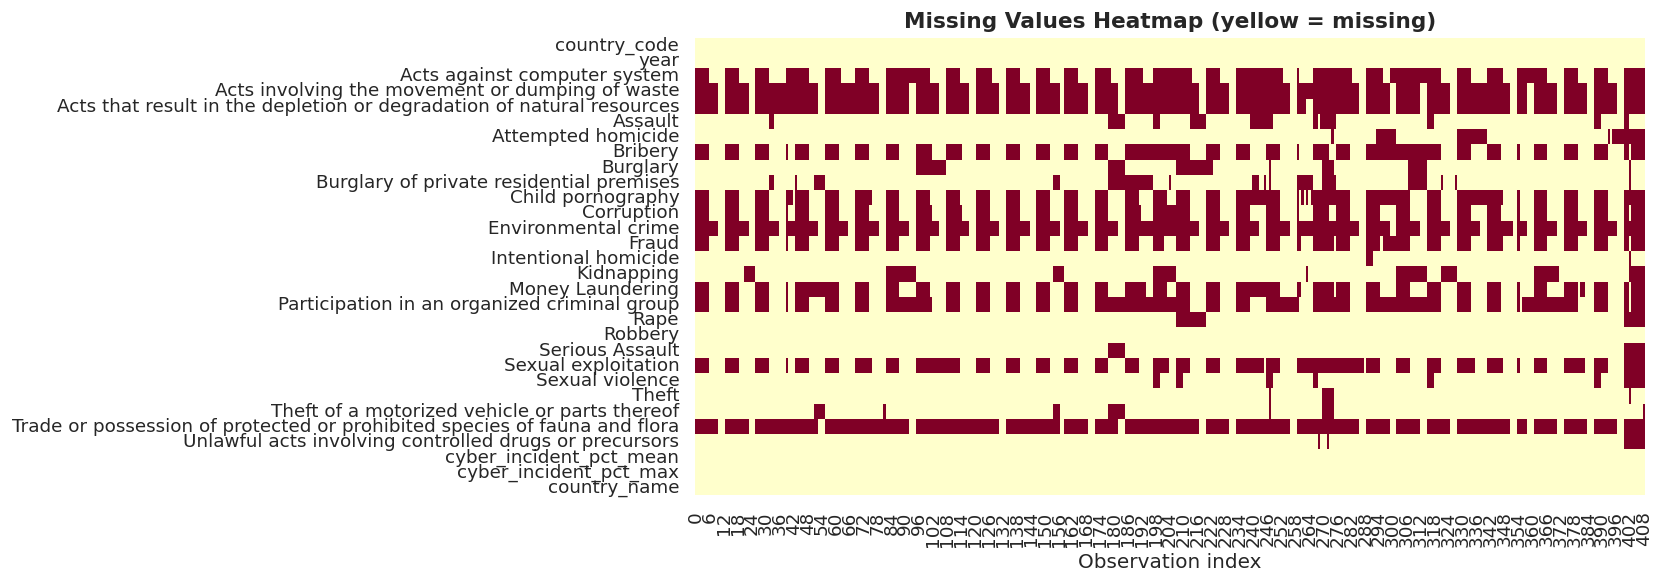

Missing value percentage per column:
Trade or possession of protected or prohibited species of fauna and flora    85.6%
Acts involving the movement or dumping of waste                              82.6%
Acts that result in the depletion or degradation of natural resources        81.9%
Environmental crime                                                          80.0%
Participation in an organized criminal group                                 61.9%
Acts against computer system                                                 59.4%
Sexual exploitation                                                          56.0%
Child pornography                                                            54.8%
Bribery                                                                      53.3%
Money Laundering                                                             52.3%
Fraud                                                                        49.1%
Corruption                                        

In [2]:
# ============================================================
# CELL 2: Missing data heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))
missing = df.isnull()
sns.heatmap(missing.T, cbar=False, yticklabels=True, cmap='YlOrRd', ax=ax)
ax.set_title('Missing Values Heatmap (yellow = missing)', fontsize=13, fontweight='bold')
ax.set_xlabel('Observation index')
plt.tight_layout()
plt.savefig('fig_missing_data.png', bbox_inches='tight')
plt.show()

print('Missing value percentage per column:')
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(miss_pct[miss_pct > 0].apply(lambda x: f'{x:.1f}%'))

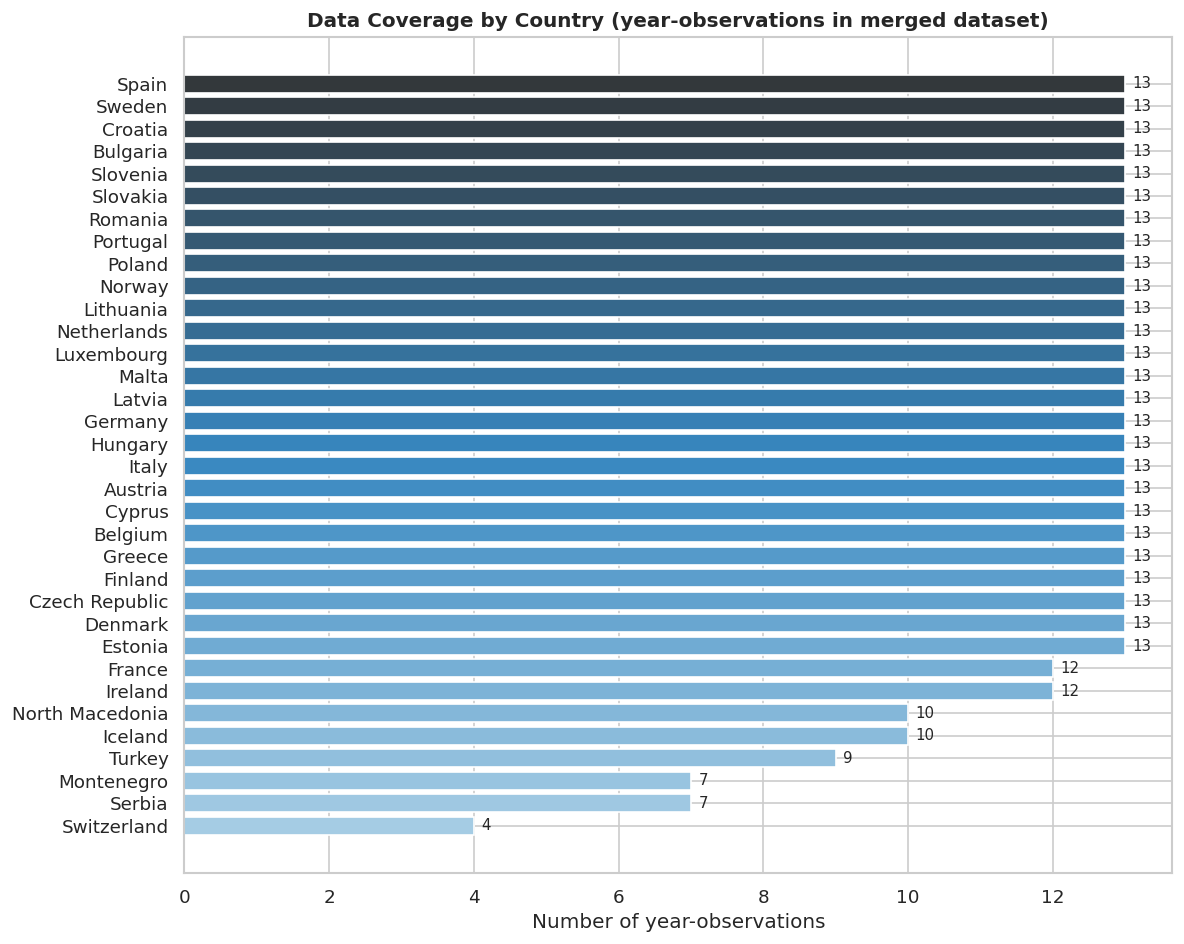

In [3]:
# ============================================================
# CELL 3: Country coverage — how many years per country?
# ============================================================

coverage = df.groupby('country_name')['year'].count().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(coverage.index, coverage.values, color=sns.color_palette('Blues_d', len(coverage)))
ax.set_xlabel('Number of year-observations')
ax.set_title('Data Coverage by Country (year-observations in merged dataset)', fontweight='bold')
for bar, val in zip(bars, coverage.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_coverage.png', bbox_inches='tight')
plt.show()

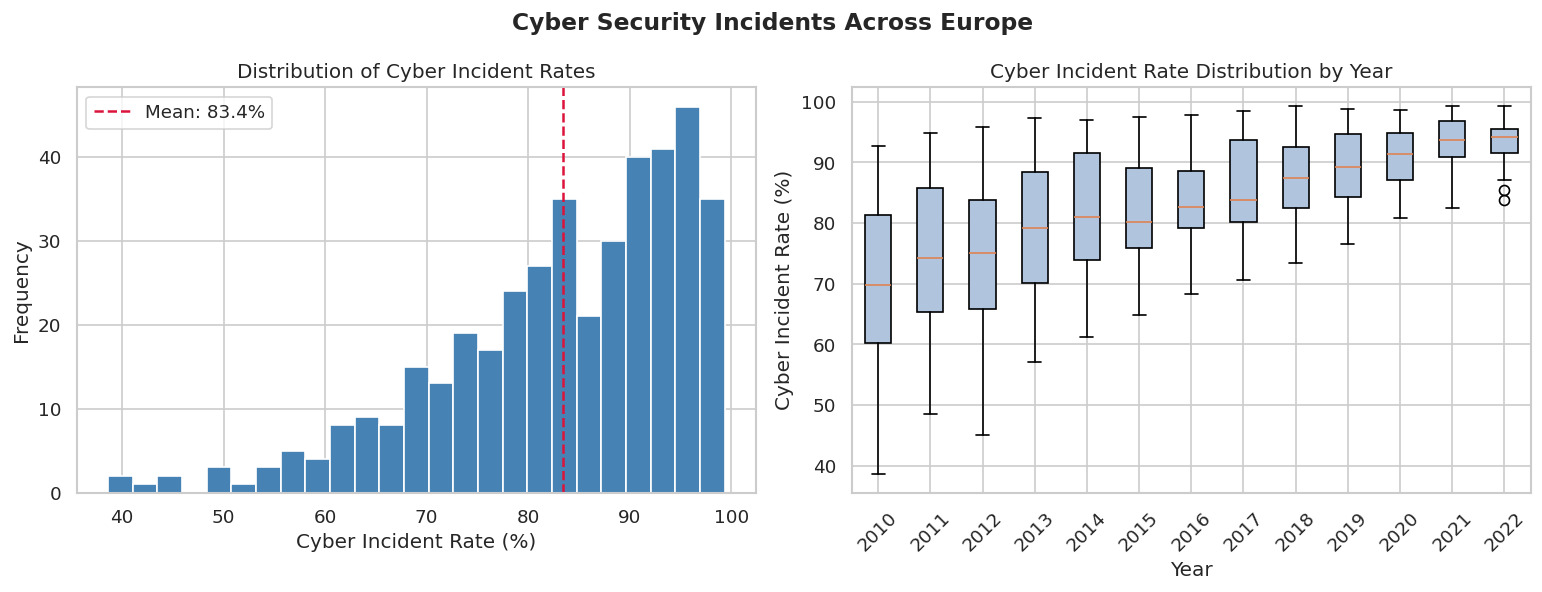

In [4]:
# ============================================================
# CELL 4: Distribution of cyber incident % across all countries
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(df['cyber_incident_pct_mean'].dropna(), bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(df['cyber_incident_pct_mean'].mean(), color='crimson', linestyle='--', label=f'Mean: {df["cyber_incident_pct_mean"].mean():.1f}%')
axes[0].set_xlabel('Cyber Incident Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Cyber Incident Rates')
axes[0].legend()

# Box plot by year
yearly = df.groupby('year')['cyber_incident_pct_mean'].apply(list).reset_index()
axes[1].boxplot([v for v in yearly['cyber_incident_pct_mean']],
                labels=[str(int(y)) for y in yearly['year']],
                patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Cyber Incident Rate (%)')
axes[1].set_title('Cyber Incident Rate Distribution by Year')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Cyber Security Incidents Across Europe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cyber_distribution.png', bbox_inches='tight')
plt.show()

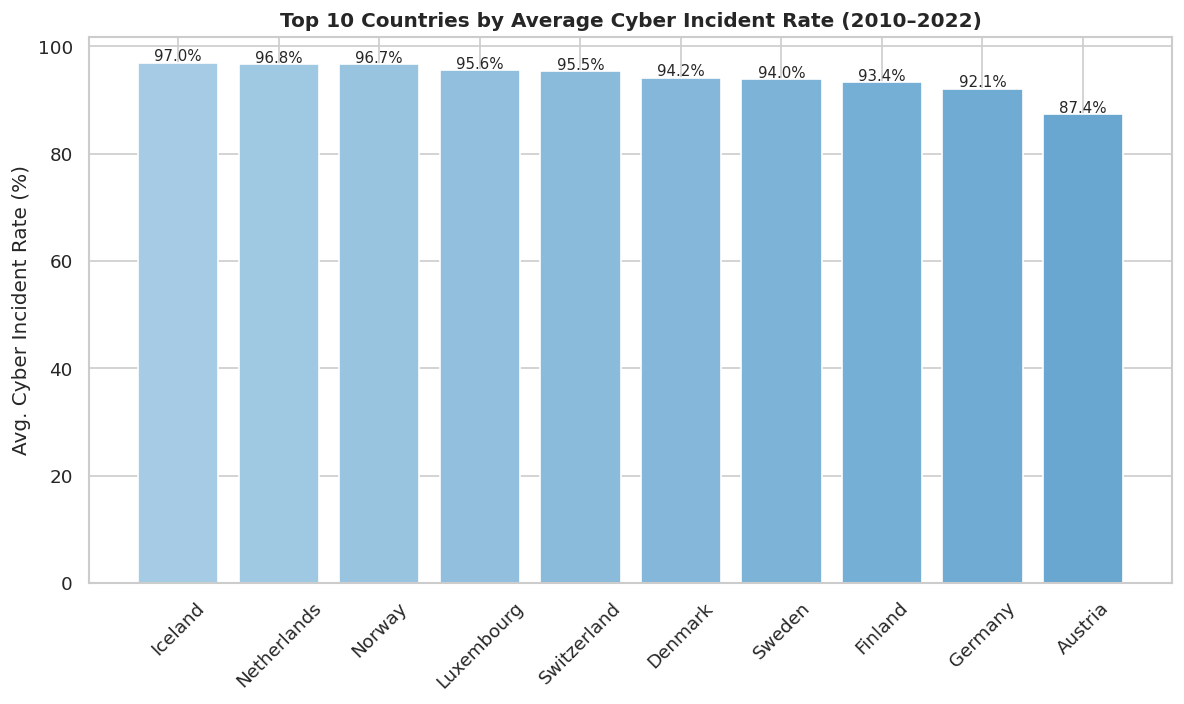

In [5]:
# ============================================================
# CELL 5: Top 10 countries by avg cyber incident rate
# ============================================================

top_cyber = (
    df.groupby('country_name')['cyber_incident_pct_mean']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('RdYlGn_r', len(top_cyber))
bars = ax.bar(top_cyber.index, top_cyber.values, color=sns.color_palette('Blues_d', len(coverage)), edgecolor='white')
ax.set_ylabel('Avg. Cyber Incident Rate (%)')
ax.set_title('Top 10 Countries by Average Cyber Incident Rate (2010–2022)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_cyber.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_top_cyber_countries.png', bbox_inches='tight')
plt.show()

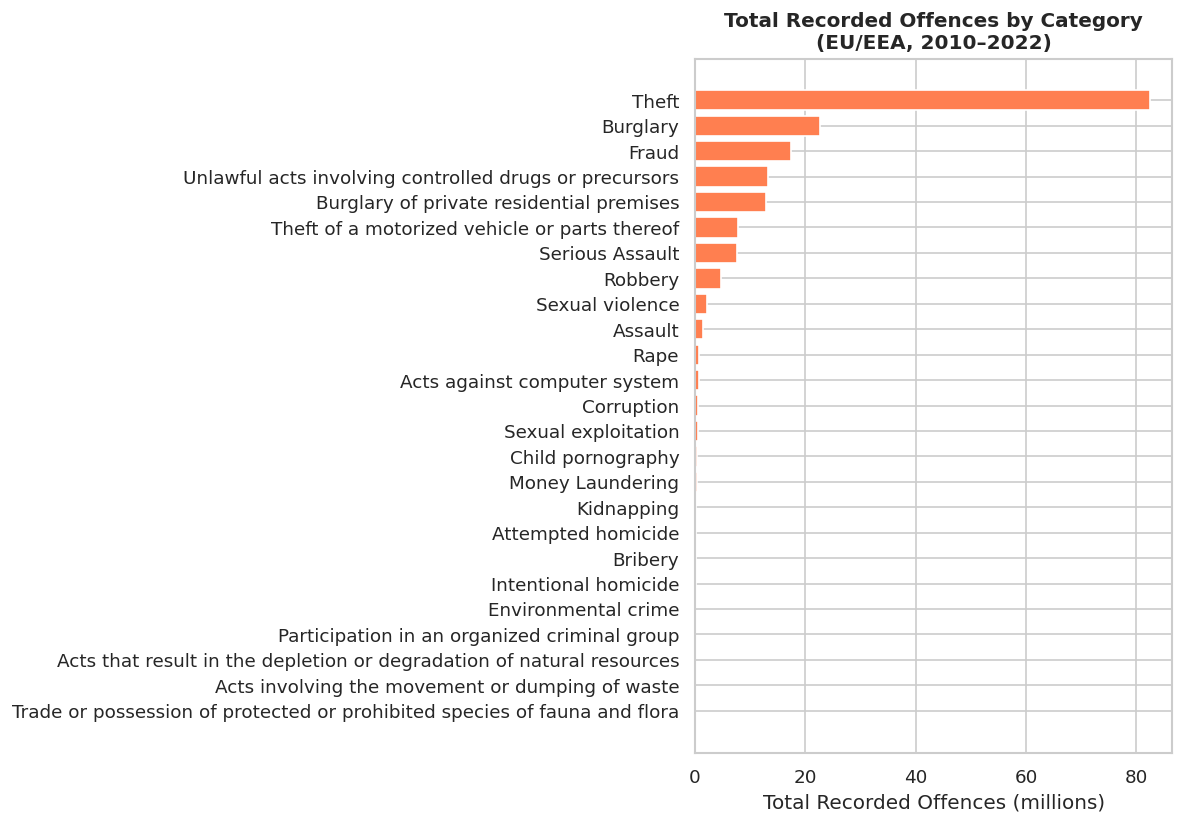

In [6]:
# ============================================================
# CELL 6: Crime categories distribution (if available)
# ============================================================

if 'crime_label' in df_crime_long.columns:
    cat_totals = (
        df_crime_long.groupby('crime_label')['crime_count']
        .sum()
        .sort_values(ascending=True)
    )
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(cat_totals.index, cat_totals.values / 1e6, color='coral', edgecolor='white')
    ax.set_xlabel('Total Recorded Offences (millions)')
    ax.set_title('Total Recorded Offences by Category\n(EU/EEA, 2010–2022)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_crime_categories.png', bbox_inches='tight')
    plt.show()
else:
    print('Crime label column not found — showing crime_count summary')
    print(df_crime_long['crime_count'].describe())

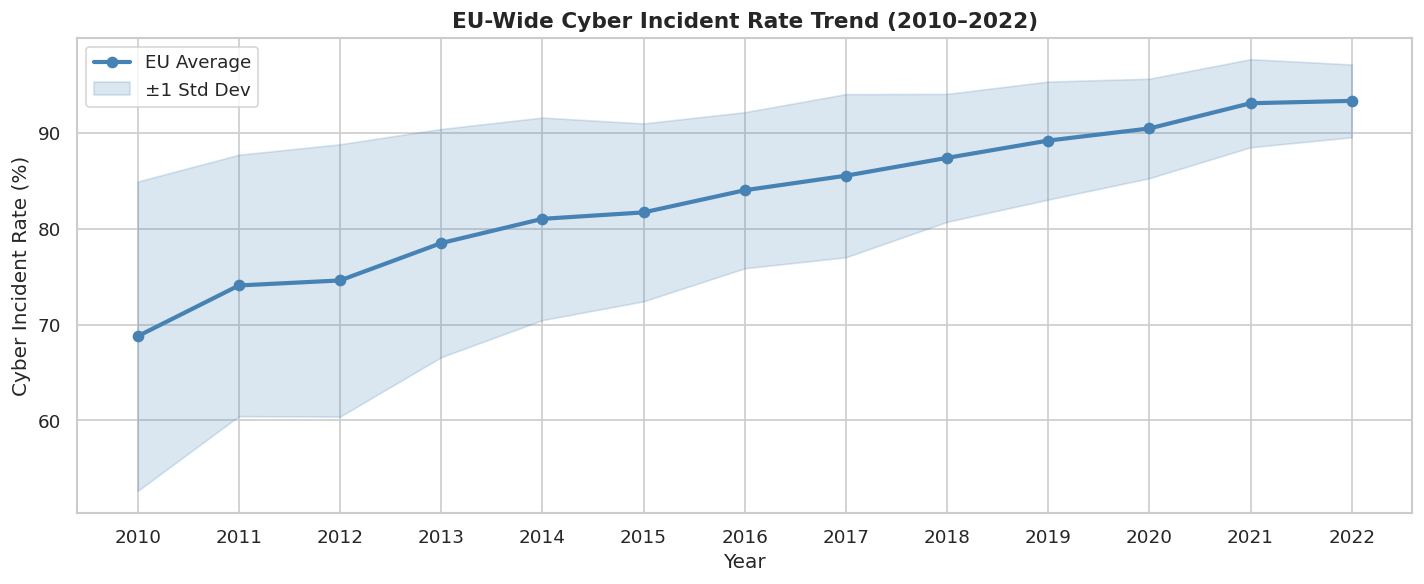

In [7]:
# ============================================================
# CELL 7: Time series — EU-wide cyber incidents trend
# ============================================================

eu_trend = df.groupby('year').agg(
    cyber_mean=('cyber_incident_pct_mean', 'mean'),
    cyber_std=('cyber_incident_pct_mean', 'std'),
    n=('country_code', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eu_trend['year'], eu_trend['cyber_mean'], marker='o', color='steelblue',
        linewidth=2.5, label='EU Average')
ax.fill_between(
    eu_trend['year'],
    eu_trend['cyber_mean'] - eu_trend['cyber_std'],
    eu_trend['cyber_mean'] + eu_trend['cyber_std'],
    alpha=0.2, color='steelblue', label='±1 Std Dev'
)
ax.set_xlabel('Year')
ax.set_ylabel('Cyber Incident Rate (%)')
ax.set_title('EU-Wide Cyber Incident Rate Trend (2010–2022)', fontsize=13, fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('fig_eu_cyber_trend.png', bbox_inches='tight')
plt.show()

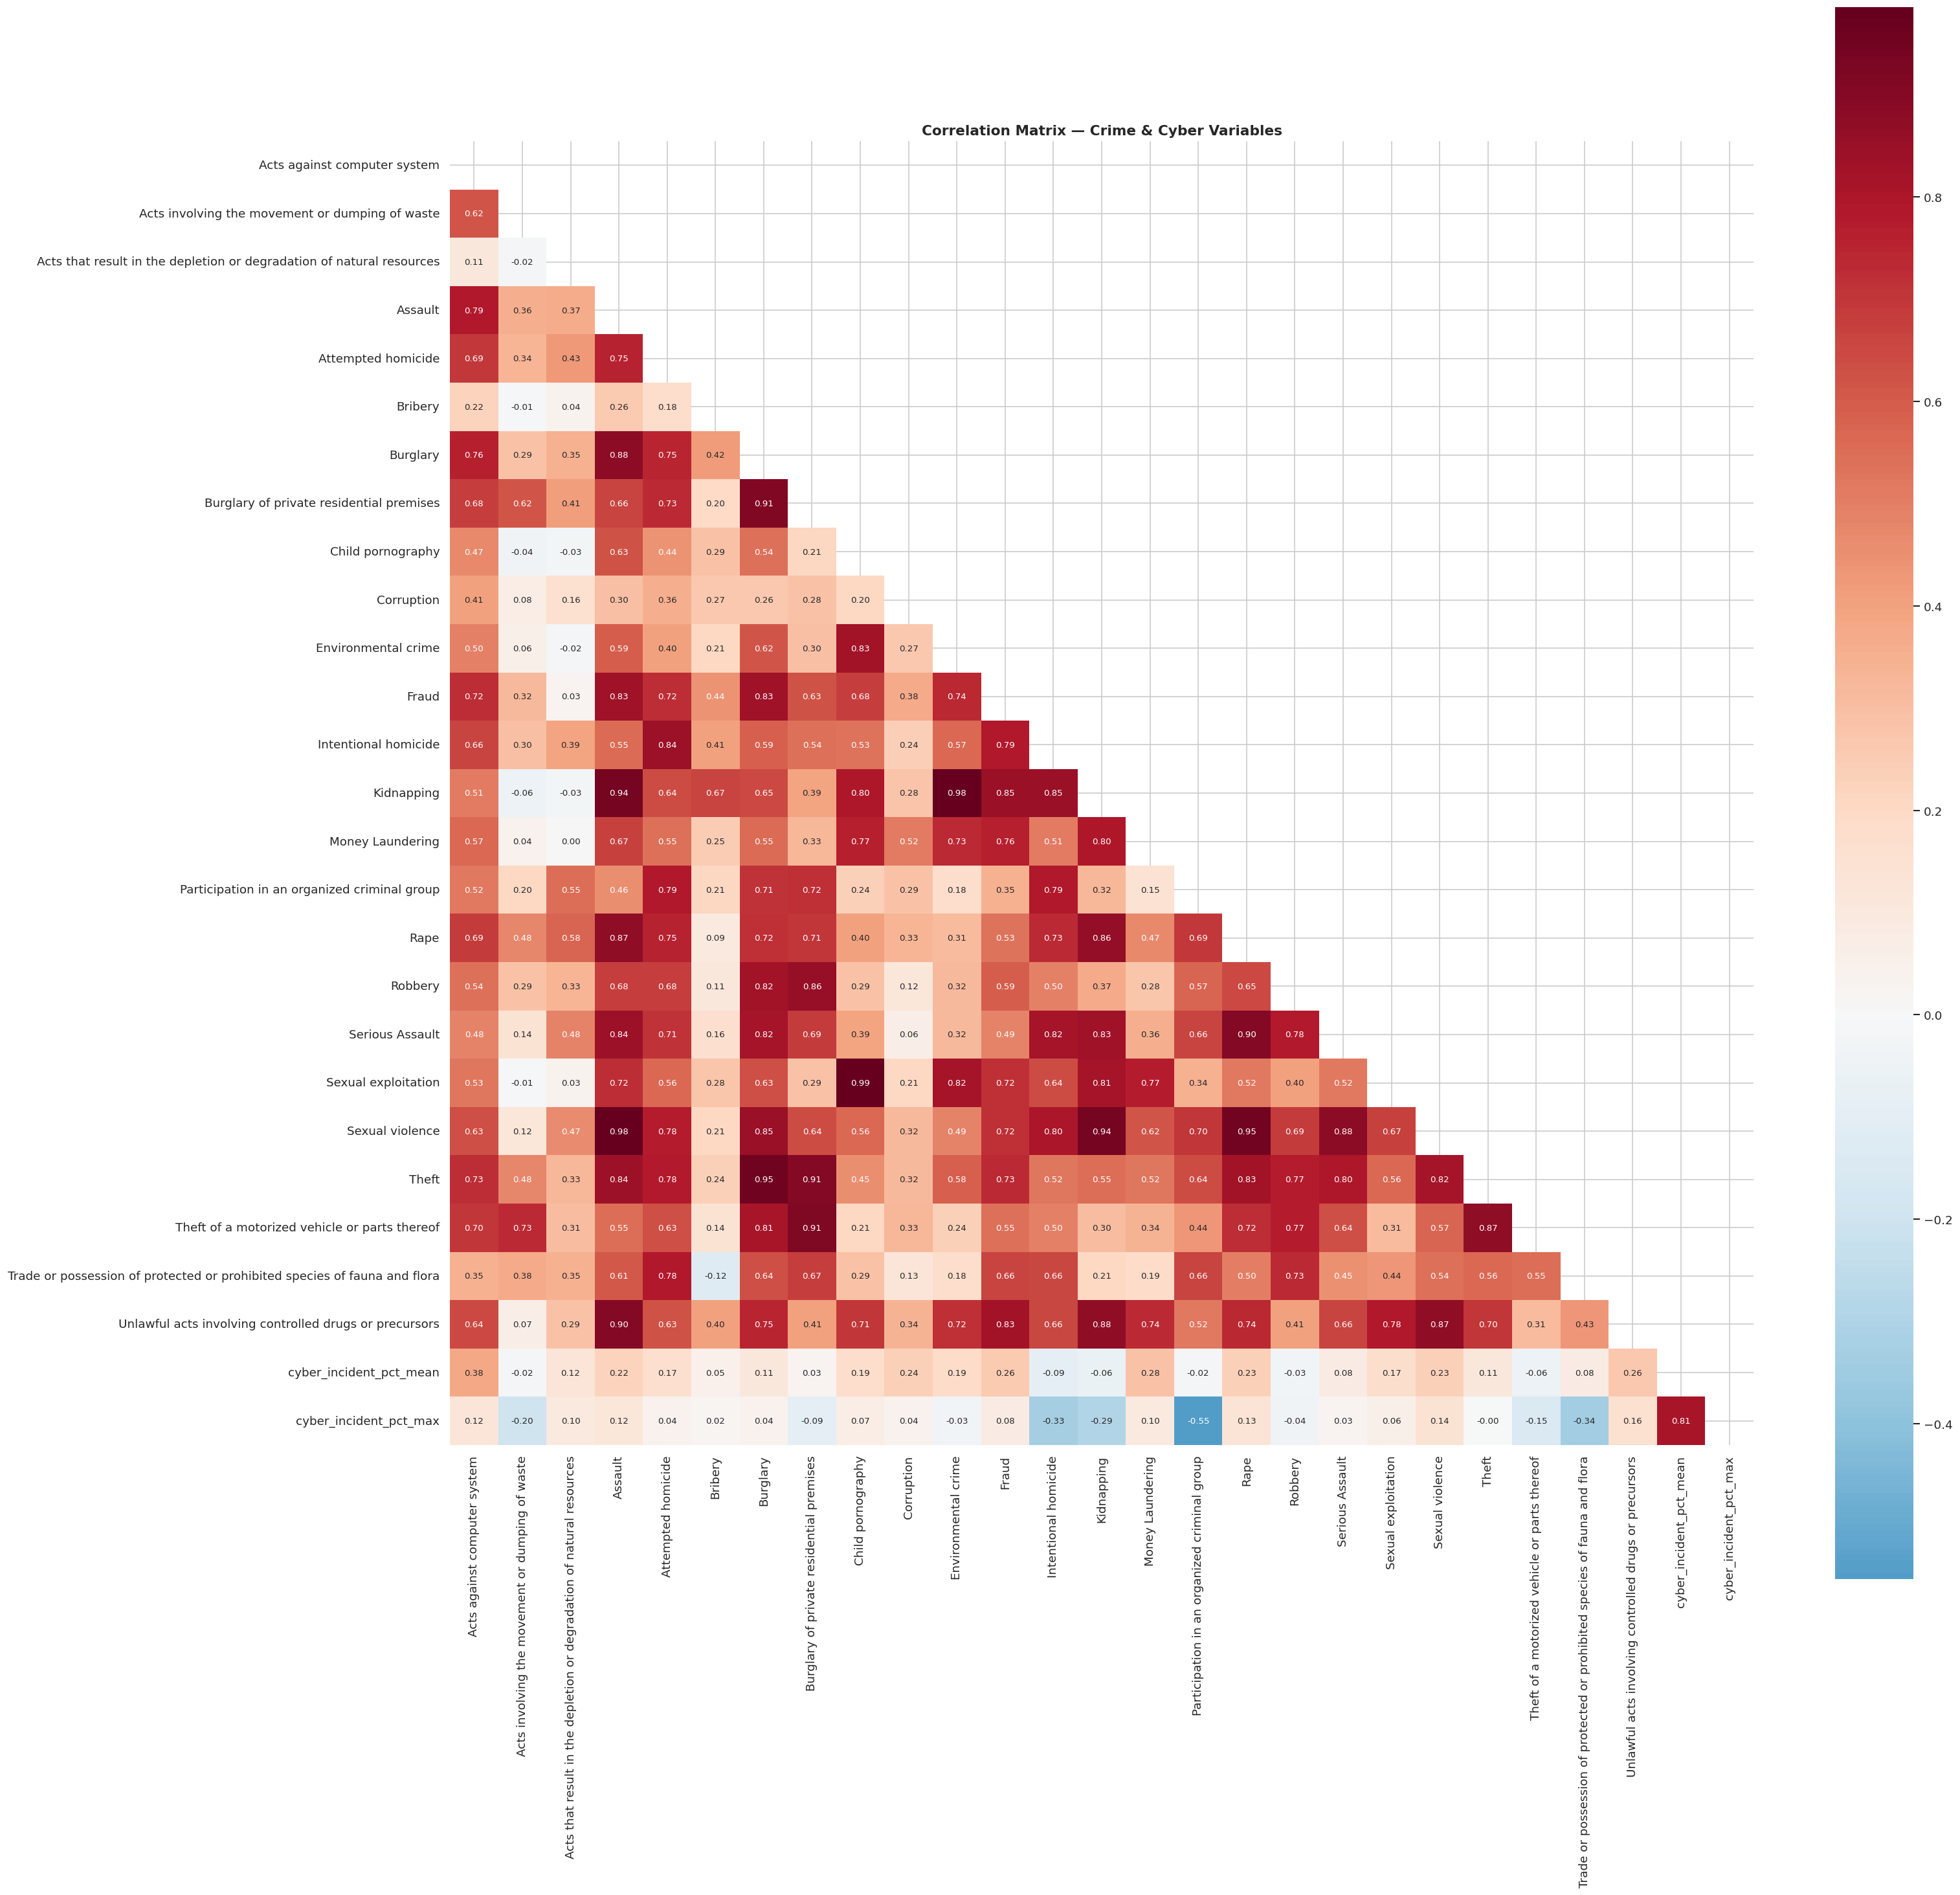


Top correlations with cyber_incident_pct_mean:
cyber_incident_pct_max                                    0.806365
Acts against computer system                              0.381435
Money Laundering                                          0.283662
Unlawful acts involving controlled drugs or precursors    0.259149
Fraud                                                     0.256253
Corruption                                                0.240165
Sexual violence                                           0.234646
Rape                                                      0.228986
Name: cyber_incident_pct_mean, dtype: float64


In [8]:
# ============================================================
# CELL 8: Correlation matrix
# ============================================================

# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['year']]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(max(10, len(numeric_cols)), max(8, len(numeric_cols)-2)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Crime & Cyber Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Highlight top correlations with cyber
if 'cyber_incident_pct_mean' in corr_matrix.columns:
    print('\nTop correlations with cyber_incident_pct_mean:')
    print(corr_matrix['cyber_incident_pct_mean'].drop('cyber_incident_pct_mean').sort_values(key=abs, ascending=False).head(8))

In [9]:
# ============================================================
# CELL 9: Interactive choropleth — cyber incident rate by country
# ============================================================

cyber_by_country = (
    df.groupby(['country_code', 'country_name'])['cyber_incident_pct_mean']
    .mean()
    .reset_index()
)

# Map EL->GRC, UK->GBR for Plotly ISO codes
iso_fix = {'EL': 'GRC', 'UK': 'GBR'}
cyber_by_country['iso3'] = cyber_by_country['country_code'].replace(iso_fix)

# For codes that are already 2-char, convert to 3-char manually
iso2_to_3 = {
    'AT':'AUT','BE':'BEL','BG':'BGR','CY':'CYP','CZ':'CZE','DE':'DEU','DK':'DNK',
    'EE':'EST','ES':'ESP','FI':'FIN','FR':'FRA','HR':'HRV','HU':'HUN','IE':'IRL',
    'IT':'ITA','LT':'LTU','LU':'LUX','LV':'LVA','MT':'MLT','NL':'NLD','PL':'POL',
    'PT':'PRT','RO':'ROU','SE':'SWE','SI':'SVN','SK':'SVK','NO':'NOR','CH':'CHE',
    'IS':'ISL','ME':'MNE','MK':'MKD','RS':'SRB','TR':'TUR'
}
cyber_by_country['iso3'] = cyber_by_country['country_code'].map(iso2_to_3)

fig = px.choropleth(
    cyber_by_country,
    locations='iso3',
    color='cyber_incident_pct_mean',
    hover_name='country_name',
    color_continuous_scale='Reds',
    scope='europe',
    title='Average Cyber Incident Rate by Country (2010–2022)',
    labels={'cyber_incident_pct_mean': 'Cyber Incident Rate (%)'}
)
fig.update_layout(height=500)
fig.show()
fig.write_html('fig_choropleth_cyber.html')

In [10]:
# ============================================================
# CELL 10: Descriptive statistics summary table
# ============================================================

summary = df.describe().T
summary['missing_pct'] = (df.isnull().sum() / len(df) * 100).round(1)
summary = summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing_pct']]
summary.columns = ['N', 'Mean', 'Std Dev', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Missing %']
summary = summary.sort_values(by='Mean', ascending=False)

print('=== DESCRIPTIVE STATISTICS SUMMARY ===')
display(summary.style.format(precision=2).background_gradient(subset=['Missing %'], cmap='YlOrRd'))
summary.to_csv('descriptive_stats.csv')
print('Saved to descriptive_stats.csv')

=== DESCRIPTIVE STATISTICS SUMMARY ===


,N,Mean,Std Dev,Min,Q1,Median,Q3,Max,Missing %
Theft,402.00,197184.04,334280.34,371.46,17641.59,78342.11,199653.13,1466766.79,1.70
Fraud,208.00,82191.02,171842.49,6.96,2543.48,10317.62,57677.13,911455.17,49.10
Burglary,358.00,60613.22,93090.76,45.08,6065.93,22935.57,75642.84,464500.36,12.50
Burglary of private residential premises,349.00,35238.54,55361.67,267.84,2923.10,9257.05,41079.43,256306.99,14.70
Unlawful acts involving controlled drugs or precursors,398.00,30614.27,63834.09,17.82,2883.26,6974.05,28485.56,366192.78,2.70
Theft of a motorized vehicle or parts thereof,386.00,19710.68,38302.36,16.53,966.64,4402.07,20193.78,199108.84,5.60
Serious Assault,393.00,18501.60,54020.21,62.36,300.50,1686.69,5145.63,392410.31,3.90
Robbery,409.00,11021.79,22515.80,54.61,614.22,1973.78,8893.08,124847.02,0.00
Sexual violence,383.00,5371.52,10613.78,18.94,413.25,1548.67,4628.31,83675.71,6.40
Acts against computer system,166.00,3848.04,5528.54,1.16,211.80,1090.86,5853.26,32775.43,59.40


Saved to descriptive_stats.csv


---

EDA outputs:
- `fig_missing_data.png`, `fig_coverage.png`, `fig_cyber_distribution.png`
- `fig_top_cyber_countries.png`, `fig_crime_categories.png`
- `fig_eu_cyber_trend.png`, `fig_correlation_matrix.png`
- `fig_choropleth_cyber.html` (interactive)
- `descriptive_stats.csv`

**➡️ Continue with: `03_analysis_and_answers.ipynb`**
